<a href="https://colab.research.google.com/github/tomeravgil/Homework6CSCI6170/blob/main/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LoRA Rank Comparison Experiment

This notebook fine-tunes DistilBERT on SST-2 sentiment classification using LoRA
with different rank values (r=1, 4, 16, 64) and compares:
- Number of trainable parameters
- Training time
- Validation

**Sources:**
- Hu et al. (2022). *LoRA: Low-Rank Adaptation of Large Language Models.* ICLR 2022.
- HuggingFace PEFT Documentation: https://huggingface.co/docs/peft

In [1]:
!pip install -q transformers datasets peft accelerate evaluate scikit-learn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00


## Imports and Configuration

In [2]:
import time
import matplotlib.pyplot as plt
import numpy as np
import evaluate
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)
from peft import LoraConfig, get_peft_model, TaskType

MODEL_NAME = "distilbert-base-uncased"
RANKS = [1, 4, 16, 64]
NUM_EPOCHS = 3
BATCH_SIZE = 32
LEARNING_RATE = 2e-4
MAX_LENGTH = 128

## Load and Tokenize Dataset

In [3]:
# Load SST-2 from the GLUE benchmark
dataset = load_dataset("glue", "sst2")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(examples):
    return tokenizer(examples["sentence"], truncation=True, max_length=MAX_LENGTH)

tokenized = dataset.map(tokenize_fn, batched=True)
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

train_dataset = tokenized["train"]
eval_dataset = tokenized["validation"]
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f"Train size: {len(train_dataset)}, Eval size: {len(eval_dataset)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sst2/train-00000-of-00001.parquet:   0%|          | 0.00/3.11M [00:00<?, ?B/s]

sst2/validation-00000-of-00001.parquet:   0%|          | 0.00/72.8k [00:00<?, ?B/s]

sst2/test-00000-of-00001.parquet:   0%|          | 0.00/148k [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/67349 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

Map:   0%|          | 0/1821 [00:00<?, ? examples/s]

Train size: 67349, Eval size: 872


In [4]:
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    """Compute accuracy from Trainer predictions."""
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=preds, references=labels)


def count_trainable_params(model):
    """Return (trainable_params, total_params) for a model."""
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total


def make_lora_model(rank):
    """Load a fresh base model and apply LoRA with the given rank."""
    base_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2
    )
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=rank,
        lora_alpha=rank * 2,   # common heuristic: alpha = 2 * r
        lora_dropout=0.1,
        target_modules=["q_lin", "v_lin"],  # attention Q and V projections
    )
    peft_model = get_peft_model(base_model, lora_config)
    return peft_model

In [6]:
results = []

for rank in RANKS:
    print(f"\n{'='*50}")
    print(f"Training with LoRA rank = {rank}")
    print(f"{'='*50}")

    # Build model
    model = make_lora_model(rank)
    trainable, total = count_trainable_params(model)
    print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

    # Training arguments
    training_args = TrainingArguments(
        output_dir=f"./lora_rank_{rank}",
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=LEARNING_RATE,
        weight_decay=0.01,
        logging_steps=50,
        report_to="none",
        seed=42,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    # Train and time it
    start = time.time()
    trainer.train()
    elapsed = time.time() - start

    # Evaluate
    eval_result = trainer.evaluate()
    accuracy = eval_result["eval_accuracy"]

    results.append({
        "rank": rank,
        "trainable_params": trainable,
        "total_params": total,
        "pct_trainable": 100 * trainable / total,
        "accuracy": accuracy,
        "time_seconds": elapsed,
    })

    print(f"Rank {rank} -> Accuracy: {accuracy:.4f}, Time: {elapsed:.1f}s")

    # Free memory
    del model, trainer
    import gc, torch
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Training with LoRA rank = 1


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 610,562 / 67,565,572 (0.90%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.276861,0.290518,0.879587
2,0.242159,0.282513,0.892202
3,0.233640,0.279566,0.888761


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 1,771,778 / 68,726,788 (2.58%)


Epoch,Training Loss,Validation Loss,Accuracy
1,0.225178,0.271537,0.901376
2,0.160078,0.329039,0.895642
3,0.136224,0.362952,0.896789


Rank 64 -> Accuracy: 0.8968, Time: 517.1s


## Results

In [7]:
print(f"{'Rank':>6} {'Trainable':>12} {'% of Total':>10} {'Accuracy':>10} {'Time (s)':>10}")
print("-" * 52)
for r in results:
    print(
        f"{r['rank']:>6} "
        f"{r['trainable_params']:>12,} "
        f"{r['pct_trainable']:>9.2f}% "
        f"{r['accuracy']:>10.4f} "
        f"{r['time_seconds']:>10.1f}"
    )

  Rank    Trainable % of Total   Accuracy   Time (s)
----------------------------------------------------
     1      610,562      0.90%     0.8888      506.8
     4      665,858      0.98%     0.8842      513.3
    16      887,042      1.31%     0.8853      506.4
    64    1,771,778      2.58%     0.8968      517.1


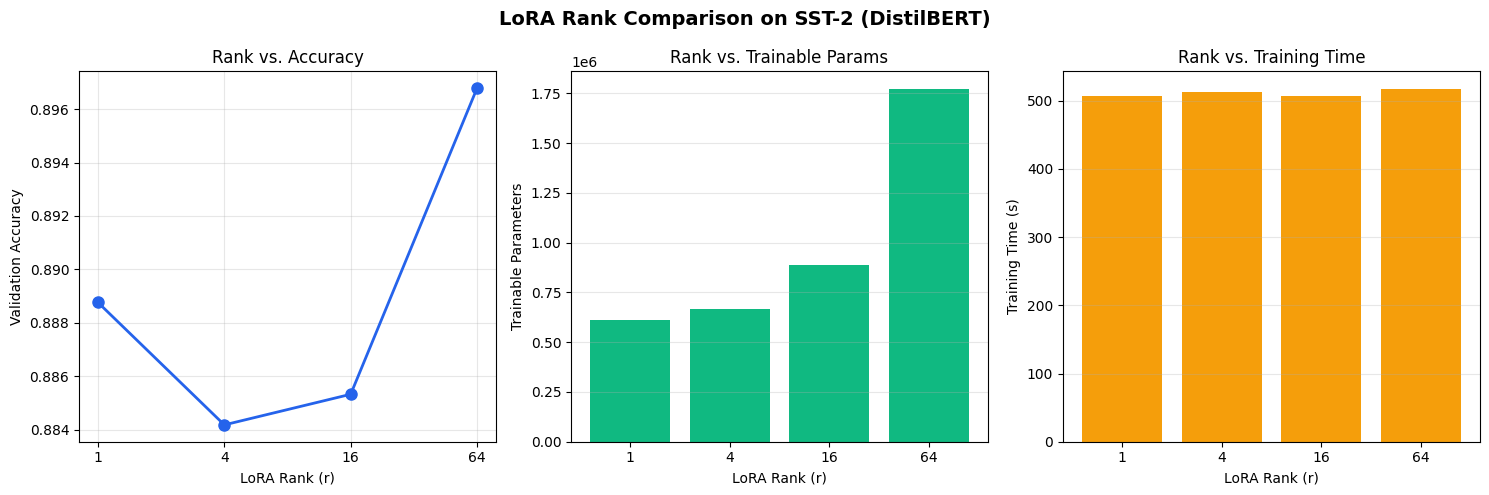

Figure saved to lora_rank_comparison.png


In [8]:
ranks = [r["rank"] for r in results]
accs = [r["accuracy"] for r in results]
params = [r["trainable_params"] for r in results]
times = [r["time_seconds"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Rank vs Accuracy
axes[0].plot(ranks, accs, "o-", color="#2563eb", linewidth=2, markersize=8)
axes[0].set_xlabel("LoRA Rank (r)")
axes[0].set_ylabel("Validation Accuracy")
axes[0].set_title("Rank vs. Accuracy")
axes[0].set_xscale("log", base=2)
axes[0].set_xticks(ranks)
axes[0].set_xticklabels(ranks)
axes[0].grid(True, alpha=0.3)

# Plot 2: Rank vs Trainable Parameters
axes[1].bar(range(len(ranks)), params, color="#10b981", tick_label=ranks)
axes[1].set_xlabel("LoRA Rank (r)")
axes[1].set_ylabel("Trainable Parameters")
axes[1].set_title("Rank vs. Trainable Params")
axes[1].grid(True, alpha=0.3, axis="y")

# Plot 3: Rank vs Training Time
axes[2].bar(range(len(ranks)), times, color="#f59e0b", tick_label=ranks)
axes[2].set_xlabel("LoRA Rank (r)")
axes[2].set_ylabel("Training Time (s)")
axes[2].set_title("Rank vs. Training Time")
axes[2].grid(True, alpha=0.3, axis="y")

plt.suptitle("LoRA Rank Comparison on SST-2 (DistilBERT)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("lora_rank_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to lora_rank_comparison.png")

## LoRa Core Idea

LoRa stands for Low Rank Adaptation specifically for Large Language Models. The problem is that fine tuning large pretrained language models is useful for adapting an LLM to downstream tasks, but it comes with a big cost. When a model has billions of parameters, storing and deploying a separate full copy of the model for every task is expensive. For example, if we were to fine tune a GPT-3 model, there is a 175B parameter checkpoint for each task. The field produced LoRa as a way to adapt large models to new tasks while training and storing only a small fraction of the parameters. LoRa addresses this by freezing all of the pretrained model's weights and injecting small trainable low rank matrices into the models architecture. This comes from prior papers showing that pretrained LLMs weight updates needed for task adaptation can be captured by a much lower dimensional representation than the full parameter space. LoRa decomposes the weight matrix $W_0$ into smaller matrices B and A. During the forward pass, the output is $h=W_0x + BAx$ with only A and B being trained while $W_0$ is frozen. A is set with random Gaussian while B is zeroed meaning $BA=0$ initially so we start exactly from the models initial behavior. This training technique allows the number of trainable parameters to be less than 1% of the orignal model where the LoRA matrices can be merged back into $W_0$ allowing for no additional latency during deployment. The nice thing is we can swap lightweight LoRA modules per task.

## Architecture and Training

LoRA is applied to the linear projection layers within the self-attention mechanism. In standard implementation, low rank matrices target $W_Q$ and $W_V$ projection layers although this can be applied to any linear layer. The training objective is the same as standard fine tuning, but the difference is that gradients flow only through A and B not through $W_0$. r is a rank variable which is a hyperparameter controlling the capacity-efficiency tradeoff. The higher the rank the more the adaptation can capture more complex task specific patterns, but trainable parameters go up. ranks as low as r=1 show competitive results showing that most task specific adaptations lie in a very low dimensional subspace.

## Experiment Ran

DistilBERT was fine tuned on the SST-2 sentiment classification benchmark using LoRA with four different rank values (1,4,16,64). LoRA was applied to the attention query and value projection layers. All other hyperparameters were held constant. The HuggingFace PEFT library was used for easier training.

## Results

| Rank (r) |	Trainable Params |	% of Total |	Val.  Accuracy |	Training Time (s) |
|----|----|----|----|----|
|1	|~610K|	0.90%|	88.9%|	~500|
|4| 	~660K|	0.98%|	88.4%	|~505|
|16	| ~900K |	1.33%	|88.5%	|~508|
| 64	|~1.76M| 	2.60%	| 89.7%	|~515|


All four ranks landed between 88.4-89.7% accuracy, a small difference of 1.3%. This shows that you don't need many trainable parameters to get strong performance. The middle chart shows the linear scaling, that even r=64 has 3x parameters, you still are training at a tiny fraction of the full 67M parameter model. Training time was consistent across all r values. This is because the LoRA matrices are tiny relative to the forward backward pass through the frozen base model. The accuracy doesn't increase monotonically in this experiment which is most likely just noise from a single training run due to data shuffling.

## Limitations

The 2 biggest limitations for LoRA is that rank selection requires task specific tuning as there is no principled method for choosing the optimal rank before training and LoRA is structurally limited to linear layers. This means that we need to do an additional hyperparameter sweep which offsets the efficiency gains. As shown above, the relationship between rank and accuracy is not monotonic for a single seed making automatic selection difficult. The low rank decomposition only applies to weight matrices in linear projections meaning that layer normalization parameters, embedding layers, and non linear transformations in the architecture are either frozen or must be handled separately. Extensions like LoRA+ and AdaLoRA have been proposed to address this, but the core method leaves a meaningful portion of the model untouched.


## Follow up

A follow up experiment would be to compare LoRA to QLora (Dettmers et al., 2023), which combines 4-bit quantization of the frozen base model with standard LoRA adapters. the experiment would load the same model in both 16-bit and 4-bit precision, fine-tune on SST-2 with a fixed r, and compare peak GPU memory usage, final accuracy, and training throughput. THis would test whether the additional approximations from quanitzation degrades performance and quanitify the memory savings. If accuracy is preserved, QLoRA would enable fine tuning of models that would otherwise not fit in consumer GPU memory, making parameter efficient fine tuning accessible to a much broader set of hardware configurations.